# DATA Preparation


In [2]:
#imports
import numpy as np
import re
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import train_test_split

## Target Data_set

In [3]:
target_df = pd.read_csv("./target_train.csv")
print(len(target_df))

3323


In [4]:
# Drop rows where 'OS_YEARS' is NaN if conversion caused any issues
target_df.dropna(subset=['OS_YEARS', 'OS_STATUS'], inplace=True)

# Contarget_dfvert 'OS_YEARS' to numeric if it isn’t already
target_df['OS_YEARS'] = pd.to_numeric(target_df['OS_YEARS'], errors='coerce')

# Ensure 'OS_STATUS' is boolean
target_df['OS_STATUS'] = target_df['OS_STATUS'].astype(bool)

#we swap os_status and os_years
target_df['OS_STATUS'], target_df['OS_YEARS'] = target_df['OS_YEARS'], target_df['OS_STATUS']

## The molecular Dataset

In [5]:
df = pd.read_csv("X_train/clinical_train.csv")
df_eval = pd.read_csv("X_test/clinical_test.csv")

# Molecular Data
maf_df = pd.read_csv("X_train/molecular_train.csv")
maf_eval = pd.read_csv("X_test/molecular_test.csv")

### Some simple processing

In [6]:
def extract_cytogenetic_features(df):
    """Extract features from cytogenetics column"""
    
    # Initialize new columns
    df['is_normal'] = df['CYTOGENETICS'].fillna('').astype(str).str.startswith('46').astype(int)
    df['has_deletion'] = df['CYTOGENETICS'].fillna('').astype(str).str.contains('del').astype(int)
    df['has_translocation'] = df['CYTOGENETICS'].fillna('').astype(str).str.contains('t\(').astype(int)
    df['has_inversion'] = df['CYTOGENETICS'].fillna('').astype(str).str.contains('inv').astype(int)
    df['has_addition'] = df['CYTOGENETICS'].fillna('').astype(str).str.contains('add').astype(int)
    
    # Check for specific chromosome abnormalities
    df['has_chr7_abnormal'] = df['CYTOGENETICS'].fillna('').astype(str).str.contains('-7|del\(7\)').astype(int)
    df['has_chr5_abnormal'] = df['CYTOGENETICS'].fillna('').astype(str).str.contains('-5|del\(5\)').astype(int)
    df['has_trisomy8'] = df['CYTOGENETICS'].fillna('').astype(str).str.contains('\+8').astype(int)
    
    # Count total abnormalities
    df['total_abnormalities'] = (
        df['has_deletion'] + 
        df['has_translocation'] + 
        df['has_inversion'] + 
        df['has_addition'] +
        df['has_chr7_abnormal'] +
        df['has_chr5_abnormal'] +
        df['has_trisomy8']
    )
    
    return df

# Apply to both training and test sets
df = extract_cytogenetic_features(df)
df_eval = extract_cytogenetic_features(df_eval)

# Let's see the distribution of the new features
for col in ['is_normal', 'has_deletion', 'has_translocation', 'has_inversion', 
            'has_addition', 'has_chr7_abnormal', 'has_chr5_abnormal', 
            'has_trisomy8', 'total_abnormalities']:
    print(f"\nFeature: {col}")
    print(df[col].value_counts())


Feature: is_normal
is_normal
1    2303
0    1020
Name: count, dtype: int64

Feature: has_deletion
has_deletion
0    2709
1     614
Name: count, dtype: int64

Feature: has_translocation
has_translocation
0    3133
1     190
Name: count, dtype: int64

Feature: has_inversion
has_inversion
0    3279
1      44
Name: count, dtype: int64

Feature: has_addition
has_addition
0    3171
1     152
Name: count, dtype: int64

Feature: has_chr7_abnormal
has_chr7_abnormal
0    3104
1     219
Name: count, dtype: int64

Feature: has_chr5_abnormal
has_chr5_abnormal
0    2940
1     383
Name: count, dtype: int64

Feature: has_trisomy8
has_trisomy8
0    3093
1     230
Name: count, dtype: int64

Feature: total_abnormalities
total_abnormalities
0    2344
1     463
2     295
3     127
4      74
5      18
6       2
Name: count, dtype: int64


<>:7: SyntaxWarning: invalid escape sequence '\('
<>:12: SyntaxWarning: invalid escape sequence '\('
<>:13: SyntaxWarning: invalid escape sequence '\('
<>:14: SyntaxWarning: invalid escape sequence '\+'
<>:7: SyntaxWarning: invalid escape sequence '\('
<>:12: SyntaxWarning: invalid escape sequence '\('
<>:13: SyntaxWarning: invalid escape sequence '\('
<>:14: SyntaxWarning: invalid escape sequence '\+'
C:\Users\marec\AppData\Local\Temp\ipykernel_48628\1244646303.py:7: SyntaxWarning: invalid escape sequence '\('
  df['has_translocation'] = df['CYTOGENETICS'].fillna('').astype(str).str.contains('t\(').astype(int)
C:\Users\marec\AppData\Local\Temp\ipykernel_48628\1244646303.py:12: SyntaxWarning: invalid escape sequence '\('
  df['has_chr7_abnormal'] = df['CYTOGENETICS'].fillna('').astype(str).str.contains('-7|del\(7\)').astype(int)
C:\Users\marec\AppData\Local\Temp\ipykernel_48628\1244646303.py:13: SyntaxWarning: invalid escape sequence '\('
  df['has_chr5_abnormal'] = df['CYTOGENETICS'].

In [7]:
def extract_cell_proportions(cytogenetics_str):
    """Extract the proportion of abnormal cells from cytogenetics string"""
    if pd.isna(cytogenetics_str):
        return 0, 0
    
    # Split different cell populations
    populations = str(cytogenetics_str).split('/')
    total_cells = 0
    abnormal_cells = 0
    
    for pop in populations:
        # Extract number of cells in square brackets
        cells = re.findall(r'\[(\d+)\]', pop)
        if cells:
            count = int(cells[0])
            total_cells += count
            # If not starting with 46, it's abnormal
            if not pop.strip().startswith('46'):
                abnormal_cells += count
    
    if total_cells == 0:
        return 0, 0
        
    return abnormal_cells, total_cells

def add_severity_features(df):
    """Add severity features based on cell proportions"""
    import re
    
    # Extract cell counts
    cell_counts = df['CYTOGENETICS'].apply(extract_cell_proportions)
    
    # Calculate proportion of abnormal cells
    df['abnormal_cell_count'] = cell_counts.apply(lambda x: x[0])
    df['total_cell_count'] = cell_counts.apply(lambda x: x[1])
    df['abnormal_cell_proportion'] = df.apply(
        lambda row: row['abnormal_cell_count'] / row['total_cell_count'] 
        if row['total_cell_count'] > 0 else 0, 
        axis=1
    )
    
    return df

# Apply to both training and test sets
df = add_severity_features(df)
df_eval = add_severity_features(df_eval)

In [8]:
df.drop(columns=['CYTOGENETICS'], inplace=True)
df_eval.drop(columns=['CYTOGENETICS'], inplace=True)

## The gene dataset

In [9]:
df_mol = pd.read_csv("X_train/molecular_train.csv")
df_eval_mol = pd.read_csv("X_test/molecular_test.csv")

In [10]:
df_mol.head()

,ID,CHR,START,END,REF,ALT,GENE,PROTEIN_CHANGE,EFFECT,VAF,DEPTH
0,P100000,11,119149248.0,119149248.0,G,A,CBL,p.C419Y,non_synonymous_codon,0.0830,1308.0
1,P100000,5,131822301.0,131822301.0,G,T,IRF1,p.Y164*,stop_gained,0.0220,532.0
2,P100000,3,77694060.0,77694060.0,G,C,ROBO2,p.?,splice_site_variant,0.4100,876.0
3,P100000,4,106164917.0,106164917.0,G,T,TET2,p.R1262L,non_synonymous_codon,0.4300,826.0
4,P100000,2,25468147.0,25468163.0,ACGAAGAGGGGGTGTTC,A,DNMT3A,p.E505fs*141,frameshift_variant,0.0898,942.0


Simple with very good reasult on Coxnet

In [11]:
def process_molecular_data(df_mol):
    """
    Process molecular data to create features based on gene mutations.

    Args:
        df_mol (pd.DataFrame): Molecular data DataFrame.

    Returns:
        pd.DataFrame: DataFrame with aggregated gene mutation features.
    """

    # Group by 'ID' and 'GENE', then count the occurrences of each gene for each ID
    gene_counts = df_mol.groupby(['ID', 'GENE']).size().unstack(fill_value=0)

    # Add a total mutation count for each ID
    gene_counts['total_mutations'] = gene_counts.sum(axis=1)

    return gene_counts  

# Process the molecular data for both training and evaluation sets
df_mol_processed = process_molecular_data(df_mol)
df_eval_mol_processed = process_molecular_data(df_eval_mol)

print("Processed Training Molecular Data:")
print(df_mol_processed.head())

Processed Training Molecular Data:
GENE     ABL1  ARID1A  ARID2  ASXL1  ASXL2  ATRX  BAP1  BCL10  BCOR  BCORL1  \
ID                                                                            
P100000     0       0      0      0      0     0     0      0     0       0   
P100001     0       0      0      0      0     0     0      0     0       0   
P100002     0       0      0      0      0     0     0      0     0       0   
P100004     0       0      0      0      0     0     0      0     0       0   
P100006     0       0      0      0      0     0     0      0     0       0   

GENE     ...  TP53  U2AF1  U2AF2  WHSC1  WT1  ZBTB33  ZMYM3  ZNF318  ZRSR2  \
ID       ...                                                                 
P100000  ...     0      0      0      0    0       0      0       0      0   
P100001  ...     0      0      0      0    0       0      0       0      0   
P100002  ...     1      0      0      0    0       0      0       0      0   
P100004  ...     0   

This process is more complexe and doesn't perform well with coxnet however seems better for CGBoost and Random Forest

In [12]:
def process_molecular_data(df_mol):
    """
    Process molecular data to create features based on gene mutations,
    top gene selection, effect types, and mutation diversity.

    Args:
        df_mol (pd.DataFrame): Molecular data DataFrame.

    Returns:
        pd.DataFrame: DataFrame with aggregated features per patient ID.
    """
    df_mol = df_mol.copy()

    # ==== 1. Sélection des top 50 gènes les plus fréquents ====
    top_genes = df_mol["GENE"].value_counts().head(50).index
    df_mol_top = df_mol[df_mol["GENE"].isin(top_genes)]

    # Bag-of-genes (top 50 uniquement)
    gene_counts = df_mol_top.groupby(['ID', 'GENE']).size().unstack(fill_value=0)

    # ==== 2. Comptage des types d'effets génétiques ====
    effect_counts = df_mol.groupby(['ID', 'EFFECT']).size().unstack(fill_value=0)

    # ==== 3. Statistiques numériques simples ====
    df_mol["SUPPORT"] = df_mol["VAF"] * df_mol["DEPTH"]
    agg_features = df_mol.groupby("ID").agg({
        "VAF": ["mean", "max"],
        "DEPTH": ["mean", "max"],
        "SUPPORT": ["mean", "sum"]
    })
    agg_features.columns = ['_'.join(col) for col in agg_features.columns]

    # ==== 4. Indicateurs de diversité ====
    diversity = df_mol.groupby("ID").agg(
        n_genes_mutated=("GENE", "nunique"),
        n_effects_seen=("EFFECT", "nunique")
    )

    # ==== 5. Total mutations ====
    total_mut = df_mol.groupby("ID").size().to_frame(name="total_mutations")

    # ==== 6. Fusion finale ====
    df_features = (
        gene_counts
        .join(effect_counts, how="left")
        .join(agg_features, how="left")
        .join(diversity, how="left")
        .join(total_mut, how="left")
        .fillna(0)  # sécurité sur les NaN
    )

    return df_features

# Traitement des jeux de données
df_mol_processed = process_molecular_data(df_mol)
df_eval_mol_processed = process_molecular_data(df_eval_mol)

print("Processed Training Molecular Data:")
print(df_mol_processed.head())


Processed Training Molecular Data:
         ARID2  ASXL1  ASXL2  BCOR  BCORL1  BRCC3  CBL  CEBPA  CSNK1A1  CTCF  \
ID                                                                             
P100000      0      0      0     0       0      0    1      0        0     0   
P100002      0      0      0     0       0      0    0      0        0     0   
P100004      0      0      0     0       0      0    0      0        0     0   
P100006      0      0      0     0       0      0    0      0        0     0   
P100007      0      0      0     0       0      0    0      0        0     0   

         ...  synonymous_codon  VAF_mean  VAF_max   DEPTH_mean  DEPTH_max  \
ID       ...                                                                
P100000  ...                 0  0.301300   0.7730   834.500000     1308.0   
P100002  ...                 0  0.397000   0.5970   398.500000      487.0   
P100004  ...                 0  0.469100   0.4691  1296.000000     1296.0   
P100006  ...       

## Dealing with missing values

To improve 

In [13]:
#We merge the processed molecular data with the clinical data
df = df.merge(df_mol_processed, on='ID', how='left')
#We fill NaN values with 0 for the new features
df.fillna(0, inplace=True)
df_eval = df_eval.merge(df_eval_mol_processed, on='ID', how='left')
#We fill NaN values with 0 for the new features
df_eval.fillna(0, inplace=True)

## Aligning and Splitting

In [14]:
#We allign the rows of the df with the target_df
df = df[df['ID'].isin(target_df['ID'])]

#We drop the ID column as it is not needed anymore
df.drop(columns=['ID', 'CENTER'], inplace=True)
df_eval.drop(columns=['ID', 'CENTER'], inplace=True)
target_df = target_df.drop(columns=['ID'])

In [15]:
# Now split
X_train, X_test, y_train, y_test = train_test_split(df, target_df, test_size=0.3, random_state=42)

In [16]:
from sksurv.util import Surv
y_train_struct = Surv.from_dataframe('OS_YEARS', 'OS_STATUS', y_train)
y_test_struct = Surv.from_dataframe('OS_YEARS', 'OS_STATUS', y_test)

# Machine Learning

In [17]:
#Importing the necessary libraries

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis , IPCRidge
from sksurv.metrics import concordance_index_censored , concordance_index_ipcw
from sklearn.impute import SimpleImputer

### A simple model

In [210]:
#We use coxnet survival analysis
coxnet = CoxnetSurvivalAnalysis(
    n_alphas=200, 
    alphas=None, 
    alpha_min_ratio='auto',
    l1_ratio=0.3,
    penalty_factor=None,
    normalize=False,
    copy_X=True,
    tol=1e-09,
    max_iter=100000,
    verbose=True,
    fit_baseline_model=False,
      )
#We fit the model
coxnet.fit(X_train, y_train_struct)      
#We predict the survival function
y_pred = coxnet.predict(X_test)

#We calculate the concordance index
c_index = concordance_index_censored (y_test_struct['OS_YEARS'], y_test_struct['OS_STATUS'], y_pred)
print(f"Coxnet Concordance Index: {c_index[0]}")
#we also calculate the IPCW concordance index
ipcw_c_index = concordance_index_ipcw(survival_test=y_test_struct, survival_train=y_train_struct, estimate= y_pred )
print(f"Coxnet IPCW Concordance Index: {ipcw_c_index[0]}")

Coxnet Concordance Index: 0.6437799565970866
Coxnet IPCW Concordance Index: 0.6187912084924445


### A more complex model

#### Gradient Boost

In [211]:
#Gradiant boost
from sksurv.ensemble import ComponentwiseGradientBoostingSurvivalAnalysis as CGBoost

# Define the learning rates to iterate over
learning_rates = [0.3, 0.25, 0.2, 0.15, 0.10, 0.05, 0.01]

# Initialize a dictionary to store the results for each learning rate
results = {}

# Loop over the learning rates
for lr in learning_rates:
    scores_ipcw = {}  # Store IPCW c-index for each n_estimators
    
    est = CGBoost(learning_rate=lr, random_state=0)
    
    # Train the model for different numbers of estimators and store the IPCW c-index
    for i in range(1, 31):
        n_estimators = 200+ i * 10
        est.set_params(n_estimators=n_estimators)
        est.fit(X_train, y_train_struct)
        
        y_pred = est.predict(X_test)
        ipcw_c_index = concordance_index_ipcw(survival_test=y_test_struct, survival_train=y_train_struct, estimate=y_pred)
        scores_ipcw[n_estimators] = ipcw_c_index[0]
    
    # Store the results for this learning rate
    results[lr] = scores_ipcw

# Plotting the results
plt.figure(figsize=(10, 6))
for lr, scores in results.items():
    x, y = zip(*scores.items())
    plt.plot(x, y, label=f"IPCW c-index (LR={lr})")

plt.xlabel("n_estimators")
plt.ylabel("IPCW c-index")
plt.title("Componentwise Gradient Boosting Survival Analysis")
plt.grid(True)
plt.legend()
plt.show()


KeyboardInterrupt: 

Componentwise Gradient Boosting IPCW Concordance Index with n_estimators=2500: 0.6658472038349884
Componentwise Gradient Boosting IPCW Concordance Index with n_estimators=5000: 0.6737956496298362
Componentwise Gradient Boosting IPCW Concordance Index with n_estimators=7500: 0.6737940861912982


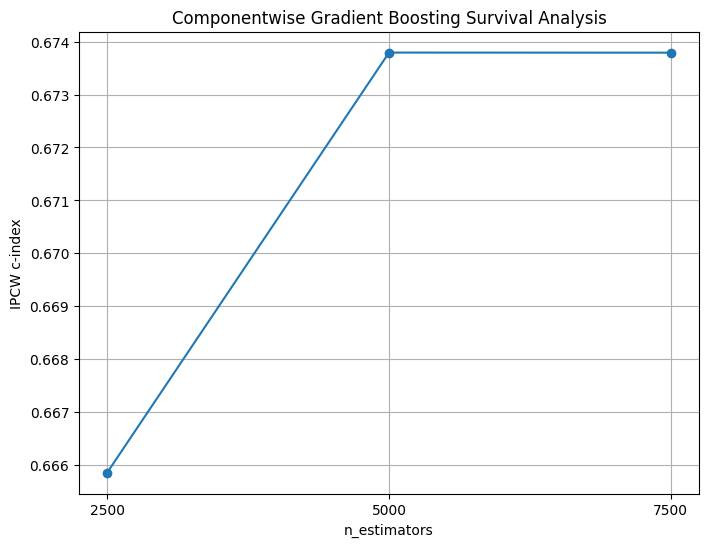

In [219]:
#Gradiant boost
from sksurv.ensemble import ComponentwiseGradientBoostingSurvivalAnalysis as CGBoost

# Define the learning rates to iterate over
learning_rates = [0.3, 0.25, 0.2, 0.15, 0.10, 0.05, 0.01]


est = CGBoost(learning_rate=0.005, random_state=0)

# Define the n_estimators values to iterate over
n_estimators_values = [2500, 5000, 7500]

# Initialize a dictionary to store the IPCW c-index for each n_estimators value
results = {}

# Loop over the n_estimators values
for n_estimators in n_estimators_values:
    est.set_params(n_estimators=n_estimators)
    est.fit(X_train, y_train_struct)

    y_pred = est.predict(X_test)
    ipcw_c_index = concordance_index_ipcw(survival_test=y_test_struct, survival_train=y_train_struct, estimate=y_pred)
    results[n_estimators] = ipcw_c_index[0]

    print(f"Componentwise Gradient Boosting IPCW Concordance Index with n_estimators={n_estimators}: {ipcw_c_index[0]}")

# Plotting the results
plt.figure(figsize=(8, 6))
plt.plot(results.keys(), results.values(), marker='o')
plt.xlabel("n_estimators")
plt.ylabel("IPCW c-index")
plt.title("Componentwise Gradient Boosting Survival Analysis")
plt.xticks(n_estimators_values)
plt.grid(True)
plt.show()

#### Survival Forest

In [ ]:
from sklearn.model_selection import GridSearchCV
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_ipcw
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import make_scorer

# Define the parameter grid to search
param_grid = {
    'n_estimators': [250, 500, 2000, 1500],
    'max_depth': [6, 8, 10],
    'min_samples_split': [2, 5, 10,15],
    'min_samples_leaf': [2, 3, 5]
}

# Define a scorer based on IPCW C-index
def ipcw_scorer(estimator, X, y):
    y_pred = estimator.predict(X)
    ipcw_c_index = concordance_index_ipcw(survival_test=y_test_struct, survival_train=y_train_struct, estimate=y_pred)
    return ipcw_c_index[0]

ipcw_scoring = make_scorer(ipcw_scorer, greater_is_better=True)

# Initialize RandomSurvivalForest model
random_survival_forest = RandomSurvivalForest(random_state=0, n_jobs=-1)

# Initialize StratifiedKFold cross-validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=random_survival_forest,
    param_grid=param_grid,
    scoring=ipcw_scoring,
    n_jobs=-1,
    verbose=1
)

# Perform grid search
grid_search.fit(X_train, y_train_struct)

# Print best parameters and score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_}")

# Evaluate the best model on the test set
best_model = grid_search.best_estimator_
y_pred_rsf = best_model.predict(X_test)

c_index_rsf = concordance_index_censored(y_test_struct['OS_YEARS'], y_test_struct['OS_STATUS'], y_pred_rsf)
print(f"Random Survival Forest Concordance Index: {c_index_rsf[0]}")

ipcw_c_index_rsf = concordance_index_ipcw(survival_test=y_test_struct, survival_train=y_train_struct, estimate= y_pred_rsf )
print(f"Random Survival Forest IPCW Concordance Index: {ipcw_c_index_rsf[0]}")

Fitting 5 folds for each of 144 candidates, totalling 720 fits


KeyboardInterrupt: 

In [18]:
from sksurv.ensemble import RandomSurvivalForest

#We use Random survival forest

# Define the Random Survival Forest model
random_survival_forest = RandomSurvivalForest(
    n_estimators=5000,
    max_depth=15,
    min_samples_split=8,
    min_samples_leaf=5,
    random_state=0,
    n_jobs=-1
)

# Train the model
random_survival_forest.fit(X_train, y_train_struct)

# Predict risk scores
y_pred_rsf = random_survival_forest.predict(X_test)

# Evaluate performance (Concordance Index)
c_index_rsf = concordance_index_censored(y_test_struct['OS_YEARS'], y_test_struct['OS_STATUS'], y_pred_rsf)
print(f"Random Survival Forest Concordance Index: {c_index_rsf[0]}")

#we also calculate the IPCW concordance index
ipcw_c_index_rsf = concordance_index_ipcw(survival_test=y_test_struct, survival_train=y_train_struct, estimate= y_pred_rsf )
print(f"Random Survival Forest IPCW Concordance Index: {ipcw_c_index_rsf[0]}")

Random Survival Forest Concordance Index: 0.7336536509968619
Random Survival Forest IPCW Concordance Index: 0.6886814200541419


In [20]:
# Align the columns of df_eval with X_train
df_eval = df_eval.reindex(columns=X_train.columns)

#We predict the survival function for the test set
y_pred_test = random_survival_forest.predict(df_eval)


In [21]:
#We export the predictions to a csv file
df = pd.read_csv("X_test/clinical_test.csv")
predictions_df = pd.DataFrame({
    'ID': df['ID'],
    'risk_score': y_pred_test,
})
predictions_df.to_csv('submission_v2.csv', index=False)